Imports

In [166]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [167]:
df = pd.read_csv("heart.csv")
df_original = df.copy()

In [168]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [200]:
print("Columns:",df.columns)
print("\nShape:",df.shape)
print("\nInformation:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplpicates:")
print(df.duplicated().sum())
print("\nStat info")
print(df.describe())

Columns: Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

Shape: (918, 12)

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    float64
 4   Cholesterol     918 non-null    float64
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(3), int64(4)

In [170]:
print(df['HeartDisease'].value_counts())

HeartDisease
1    508
0    410
Name: count, dtype: int64


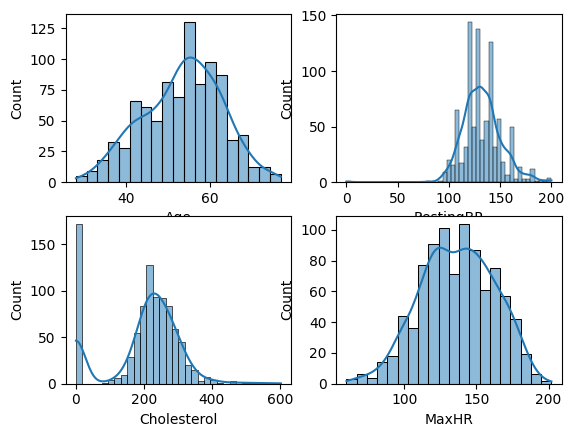

In [171]:
def plotting(var, num):
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde = True)
plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)

In [172]:
df['Cholesterol'].value_counts()

Cholesterol
0      172
254     11
220     10
223     10
204      9
      ... 
353      1
278      1
157      1
176      1
131      1
Name: count, Length: 222, dtype: int64

In [173]:
ch_mean = df.loc[df['Cholesterol']!= 0, 'Cholesterol'].mean()

In [174]:
df['Cholesterol'] = df['Cholesterol'].replace(0,ch_mean)
df['Cholesterol'] = df['Cholesterol'].round(2)

In [175]:
rb_mean = df.loc[df['RestingBP']!= 0, 'RestingBP'].mean()

In [176]:
df['RestingBP'] = df['RestingBP'].replace(0,rb_mean)
df['RestingBP'] = df['RestingBP'].round(2)

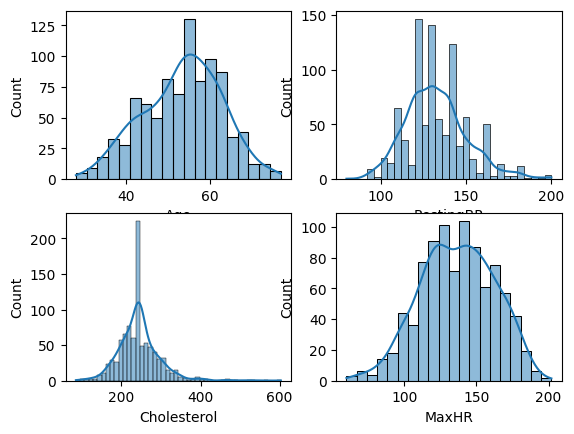

In [177]:
def plotting(var, num):
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde = True)
plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)

<Axes: xlabel='Sex', ylabel='count'>

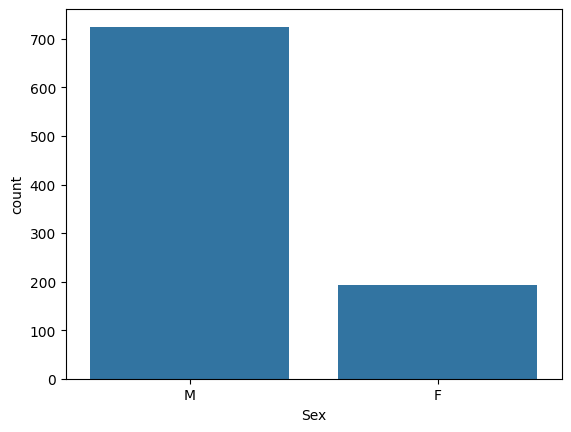

In [178]:
sns.countplot(x = df['Sex'])

<Axes: xlabel='ChestPainType', ylabel='count'>

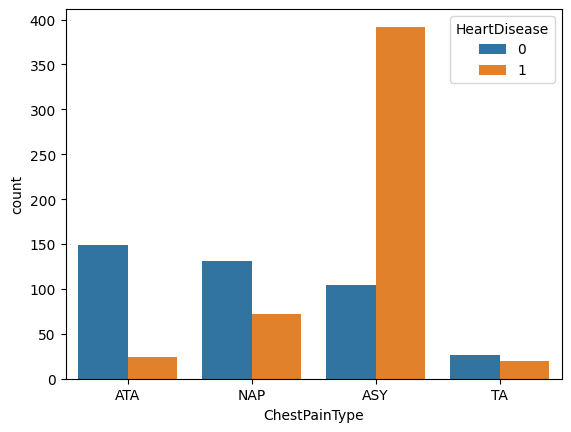

In [179]:
sns.countplot(x = df['ChestPainType'],hue=df['HeartDisease'])

<Axes: xlabel='FastingBS', ylabel='count'>

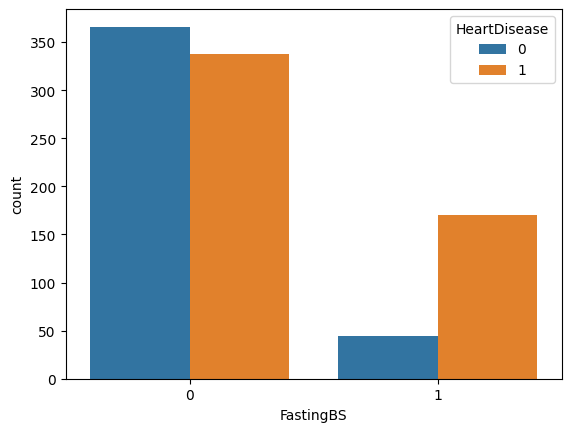

In [180]:
sns.countplot(x = df['FastingBS'],hue=df['HeartDisease'])

<Axes: xlabel='Cholesterol'>

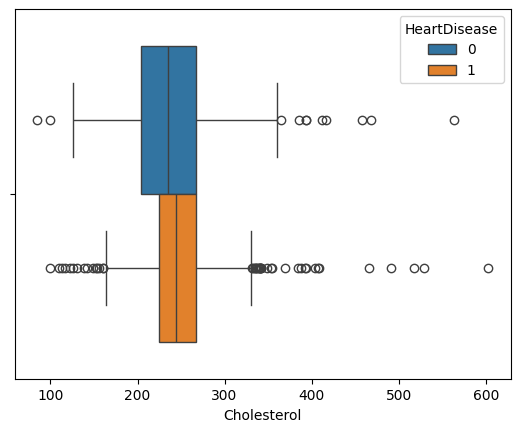

In [181]:
sns.boxplot(x = df['Cholesterol'],hue=df['HeartDisease'])

<Axes: xlabel='HeartDisease', ylabel='Age'>

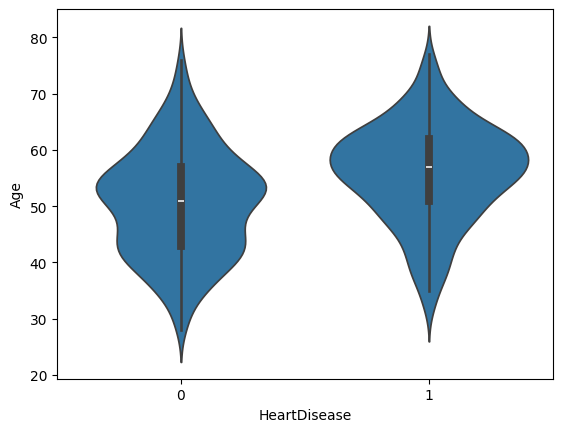

In [182]:
sns.violinplot(x = df['HeartDisease'],y ='Age',data=df)

In [183]:
df_cleaned = df.copy()

In [184]:
numerical_features = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "MaxHR",
    "Oldpeak"
]

In [185]:
categorical_features = [
    "Sex",
    "ChestPainType",
    "FastingBS",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]

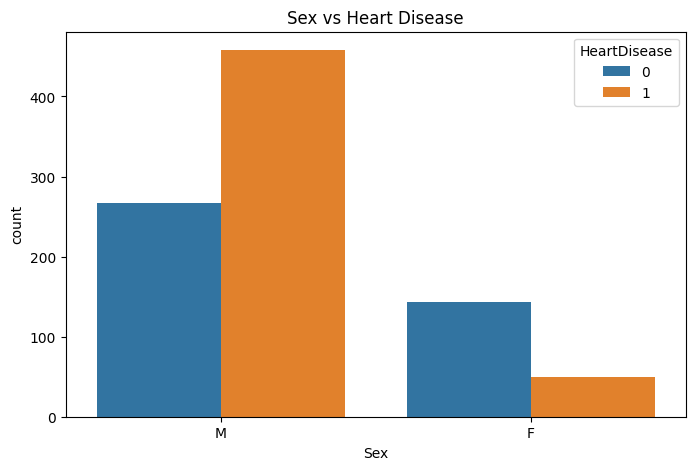

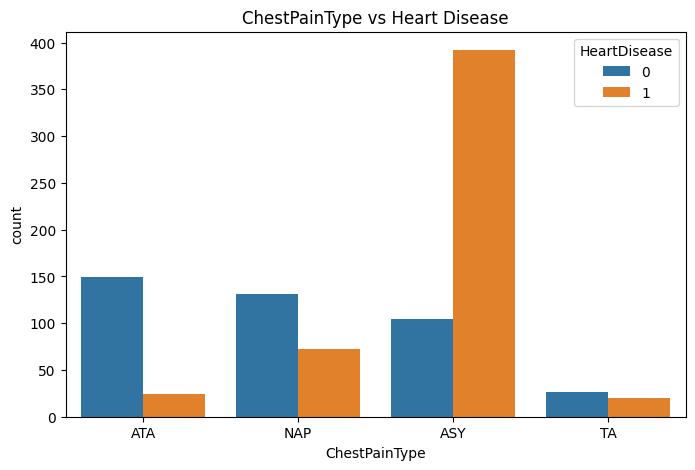

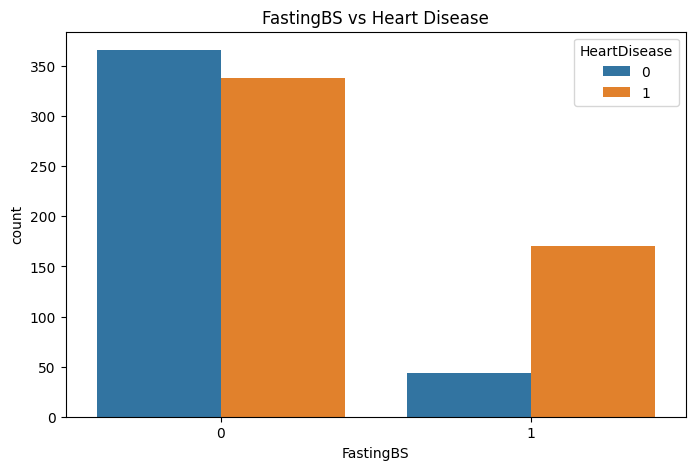

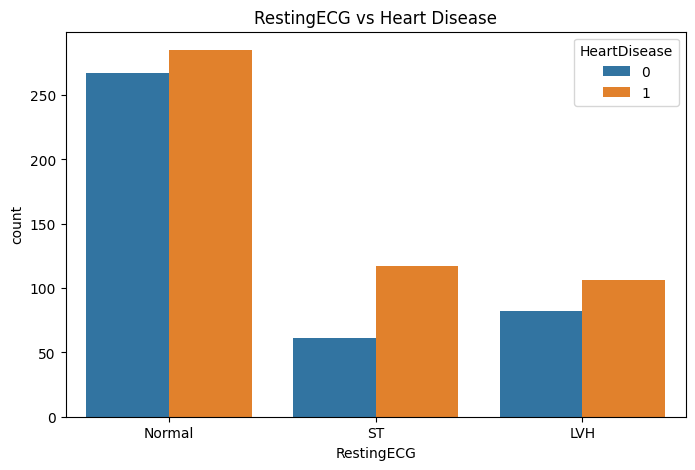

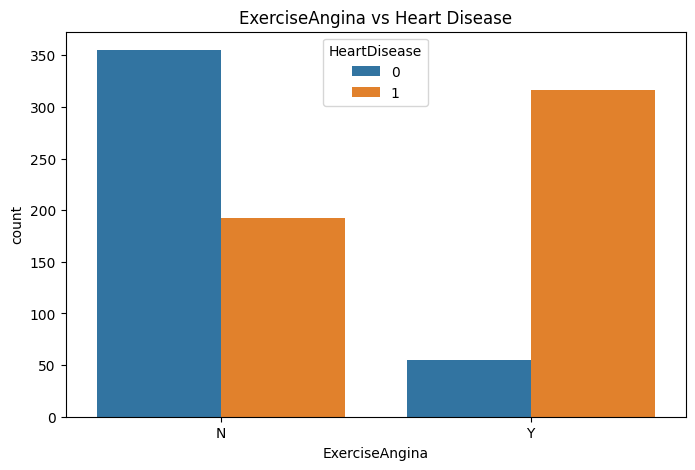

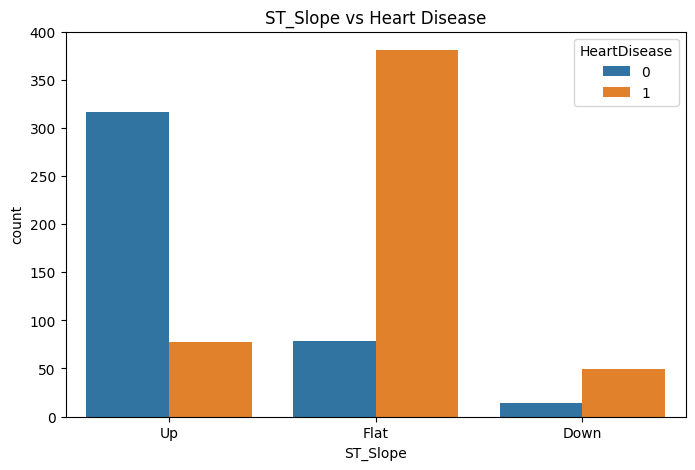

In [186]:
for feature in categorical_features:

    plt.figure(figsize=(8, 5))

    sns.countplot(
        data=df_cleaned,
        x=feature,
        hue="HeartDisease"
    )

    plt.title(f"{feature} vs Heart Disease")

    plt.show()

In [187]:
for feature in categorical_features:

    print(f"\n{feature} vs HeartDisease")

    display(
        pd.crosstab(
            df_cleaned[feature],
            df_cleaned["HeartDisease"],
            normalize="index"
        )
    )


Sex vs HeartDisease


HeartDisease,0,1
Sex,,
F,0.740933,0.259067
M,0.368276,0.631724



ChestPainType vs HeartDisease


HeartDisease,0,1
ChestPainType,,
ASY,0.209677,0.790323
ATA,0.861272,0.138728
NAP,0.645320,0.354680
TA,0.565217,0.434783



FastingBS vs HeartDisease


...

HeartDisease,0,1
RestingECG,,
LVH,0.436170,0.563830
Normal,0.483696,0.516304
ST,0.342697,0.657303



ExerciseAngina vs HeartDisease


HeartDisease,0,1
ExerciseAngina,,
N,0.648995,0.351005
Y,0.148248,0.851752



ST_Slope vs HeartDisease


HeartDisease,0,1
ST_Slope,,
Down,0.222222,0.777778
Flat,0.171739,0.828261
Up,0.802532,0.197468


<Axes: >

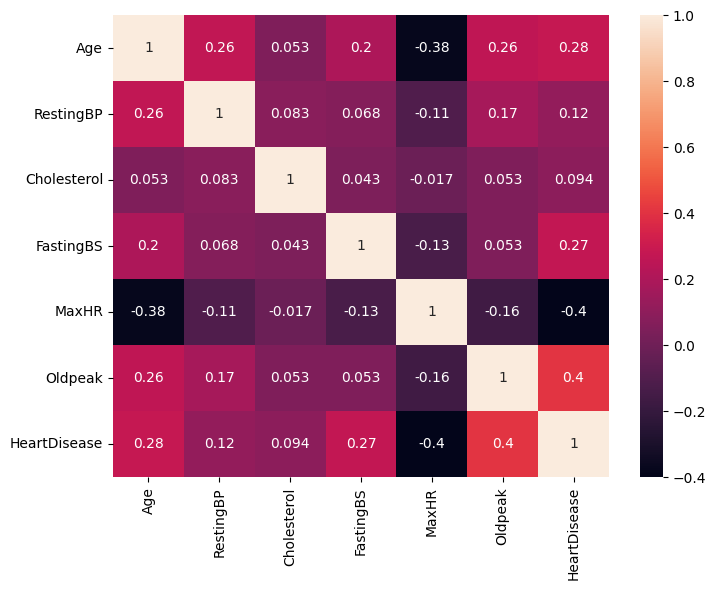

In [188]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only = True),annot=True)

Data Preprocessing

In [189]:
df_model = df_cleaned.copy()

In [190]:
X = df_model.drop("HeartDisease", axis=1)

y = df_model["HeartDisease"]

In [191]:
print("Feature Shape",X.shape)
print("Target Shape",y.shape)

Feature Shape (918, 11)
Target Shape (918,)


In [192]:
X_encoded = pd.get_dummies(
    X,
    drop_first=True
)

In [193]:
X_encoded.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.5,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,0.0,True,False,True,False,True,False,False,False,True


In [199]:
X_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                918 non-null    int64  
 1   RestingBP          918 non-null    float64
 2   Cholesterol        918 non-null    float64
 3   FastingBS          918 non-null    int64  
 4   MaxHR              918 non-null    int64  
 5   Oldpeak            918 non-null    float64
 6   Sex_M              918 non-null    bool   
 7   ChestPainType_ATA  918 non-null    bool   
 8   ChestPainType_NAP  918 non-null    bool   
 9   ChestPainType_TA   918 non-null    bool   
 10  RestingECG_Normal  918 non-null    bool   
 11  RestingECG_ST      918 non-null    bool   
 12  ExerciseAngina_Y   918 non-null    bool   
 13  ST_Slope_Flat      918 non-null    bool   
 14  ST_Slope_Up        918 non-null    bool   
dtypes: bool(9), float64(3), int64(3)
memory usage: 51.2 KB


In [195]:
X_train,X_test,y_train,y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [196]:
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("\nTraining Target Distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting Target Distribution:")
print(y_test.value_counts(normalize=True))

Training Features: (734, 15)
Testing Features: (184, 15)

Training Target Distribution:
HeartDisease
1    0.553134
0    0.446866
Name: proportion, dtype: float64

Testing Target Distribution:
HeartDisease
1    0.554348
0    0.445652
Name: proportion, dtype: float64


In [197]:
scaler  = StandardScaler()
X_train[numerical_features] = scaler.fit_transform(
    X_train[numerical_features]
)
X_test[numerical_features] = scaler.transform(
    X_test[numerical_features]
)

In [198]:
print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)

print("\nMissing Values in X_train:")
print(X_train.isnull().sum().sum())

print("\nMissing Values in X_test:")
print(X_test.isnull().sum().sum())

print("\nTraining Data:")
display(X_train.head())

print("\nTesting Data:")
display(X_test.head())

X_train Shape: (734, 15)
X_test Shape: (184, 15)

Missing Values in X_train:
0

Missing Values in X_test:
0

Training Data:


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
485,0.970012,0.339016,-0.539951,1,-0.324520,0.317046,True,True,False,False,False,True,True,True,False
486,0.122028,-1.266031,-0.595382,1,1.689837,-0.440356,True,True,False,False,False,True,False,False,True
117,0.546020,-0.159102,1.695768,1,-0.247045,0.601071,False,False,False,False,False,True,True,True,False
361,-0.725956,1.501291,-0.029246,0,-0.479470,-0.819056,True,False,False,False,True,False,True,True,False
296,-0.407962,0.671094,-0.029246,1,0.101594,-0.156330,True,False,False,False,True,False,True,True,False



Testing Data:


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
356,-0.831954,-0.989299,-0.029246,0,-0.905584,0.601071,True,False,False,False,True,False,True,True,False
763,0.440022,-0.048409,-0.410612,0,1.418673,2.210549,True,False,True,False,False,False,False,False,True
817,0.652018,-0.435834,0.217607,0,0.179069,1.831848,True,False,False,False,False,False,True,True,False
735,-0.513960,-0.712567,-1.075784,0,0.101594,1.074447,True,False,True,False,True,False,False,True,False
892,-1.573940,0.283669,-0.484520,0,0.605183,-0.819056,False,False,True,False,True,False,False,True,False
